# Validation and tuning

Before trusting a strategy you want to know how it behaves on data it was not fitted to, and you
want its hyperparameters chosen by that out-of-sample performance rather than by hand.
`PortfolioOptimisers.jl` provides cross-validation splitters and cross-validated parameter
search that work with *any* optimiser. This page shows the minimal path; for the full menu of
splitters and search strategies see the
[validation & tuning examples](../examples/5_validation_tuning/01_Cross_Validation.md).

In [1]:
using PortfolioOptimisers, CSV, TimeSeries, Clarabel, StatsPlots, GraphRecipes

X = TimeArray(CSV.File(joinpath(@__DIR__, "../examples/SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X)

slv = Solver(; name = :clarabel, solver = Clarabel.Optimizer,
             settings = Dict("verbose" => false),
             check_sol = (; allow_local = true, allow_almost = true))

mr = MeanRisk(; opt = JuMPOptimiser(; slv = slv))

MeanRisk
  opt ┼ JuMPOptimiser
      │        pe ┼ EmpiricalPrior
      │           │        ce ┼ PortfolioOptimisersCovariance
      │           │           │   ce ┼ Covariance
      │           │           │      │    me ┼ SimpleExpectedReturns
      │           │           │      │       │   w ┴ nothing
      │           │           │      │    ce ┼ GeneralCovariance
      │           │           │      │       │   ce ┼ SimpleCovariance: SimpleCovariance(true)
      │           │           │      │       │    w ┴ nothing
      │           │           │      │   alg ┴ FullMoment()
      │           │           │   mp ┼ MatrixProcessing
      │           │           │      │     pdm ┼ Posdef
      │           │           │      │         │      alg ┼ UnionAll: NearestCorrelationMatrix.Newton
      │           │           │      │         │   kwargs ┴ @NamedTuple{}: NamedTuple()
      │           │           │      │      dn ┼ nothing
      │           │           │      │      dt ┼ no

## 1. Cross-validation

A cross-validation splitter partitions the timeline into training and testing folds.
`KFold` is the simplest — `n` contiguous folds, each held out in turn.
`cross_val_predict` fits the optimiser on each training fold and stitches the
out-of-sample predictions back together, so you can score the strategy on data it never saw.

In [2]:
kfold = KFold(; n = 3)
pred = cross_val_predict(mr, rd, kfold)

MultiPeriodPredictionResult
  pred ┼ 3-element Vector{PredictionResult}
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
   mrd ┼ PredictionReturnsResult
       │     nx ┼ 20-element SubArray{String, 1, Vector{String}, Tuple{Base.Slice{Base.OneTo{Int64}}}, true}
       │      X ┼ 252-element Vector{Float64}
       │     nf ┼ nothing
       │      F ┼ nothing
       │     nb ┼ nothing
       │      B ┼ nothing
       │     ts ┼ 252-element Vector{Date}
       │     iv ┼ nothing
       │   ivpa ┴ nothing
    id ┴ nothing


The stitched predictions carry an out-of-sample realised risk, here the second moment of the
predicted returns via `expected_risk`.

In [3]:
cv_risk = expected_risk(LowOrderMoment(; alg = SecondMoment()), pred)

0.00010006296287394897

For a more exhaustive evaluation, `CombinatorialCrossValidation` scores every
train/test fold combination — heavier, but a fuller picture. See
[Cross Validation](../examples/5_validation_tuning/01_Cross_Validation.md).

## 2. Hyperparameter tuning

`GridSearchCrossValidation` searches a parameter grid and keeps the combination that
scores best on the test folds. The grid is a list of `"path" => values` pairs, where the path is
a string lens into the estimator (parsed by [Accessors.jl](https://github.com/JuliaObjects/Accessors.jl));
a scoring rule like `MeanReturnRiskRatio` ranks the candidates.
`search_cross_validation` runs the search and returns the tuned estimator in its `opt`
field. Here we tune the L1 regularisation strength of our `MeanRisk`.

In [4]:
score = MeanReturnRiskRatio(; rk = LowOrderMoment(; alg = SecondMoment()))
grid = [["opt.l1" => [0.001, 0.01, 0.05]]]

gs_res = search_cross_validation(mr, GridSearchCrossValidation(grid; r = score), rd)

SearchCrossValidationResult
           opt ┼ MeanRisk
               │   opt ┼ JuMPOptimiser
               │       │        pe ┼ EmpiricalPrior
               │       │           │        ce ┼ PortfolioOptimisersCovariance
               │       │           │           │   ce ┼ Covariance
               │       │           │           │      │    me ┼ SimpleExpectedReturns
               │       │           │           │      │       │   w ┴ nothing
               │       │           │           │      │    ce ┼ GeneralCovariance
               │       │           │           │      │       │   ce ┼ SimpleCovariance: SimpleCovariance(true)
               │       │           │           │      │       │    w ┴ nothing
               │       │           │           │      │   alg ┴ FullMoment()
               │       │           │           │   mp ┼ MatrixProcessing
               │       │           │           │      │     pdm ┼ Posdef
               │       │           │           │ 

The tuned estimator optimises like any other.

In [5]:
res_tuned = optimise(gs_res.opt, rd)

MeanRiskResult
  jr ┼ JuMPOptimisationResult
     │        pa ┼ ProcessedJuMPOptimiserAttributes
     │           │        pr ┼ LowOrderPrior
     │           │           │         X ┼ 252×20 Matrix{Float64}
     │           │           │        mu ┼ 20-element Vector{Float64}
     │           │           │     sigma ┼ 20×20 Matrix{Float64}
     │           │           │      chol ┼ nothing
     │           │           │         w ┼ nothing
     │           │           │       ens ┼ nothing
     │           │           │       kld ┼ nothing
     │           │           │        ow ┼ nothing
     │           │           │        rr ┼ nothing
     │           │           │      f_mu ┼ nothing
     │           │           │   f_sigma ┼ nothing
     │           │           │       f_w ┴ nothing
     │           │        wb ┼ WeightBounds
     │           │           │   lb ┼ 20-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}
     │          

`RandomisedSearchCrossValidation` samples the grid (or distributions) instead of
enumerating it — cheaper for large spaces; see
[Hyperparameter Tuning](../examples/5_validation_tuning/02_Hyperparameter_Tuning.md).

## 3. Time-dependent inputs

Under cross-validation each fold is a separate optimisation over its own slice of time, and any
*problem-definition* input — constraints, priors, risk measures, objectives, even the fallback
optimiser — can be told to change with it. Wrap a per-fold vector (or a function of the fold's
context) in `TimeDependent` and store it in the field it varies; the fold loop swaps
entry `i` in for fold `i`. Execution-control inputs (solvers, RNGs) stay static. Here the
per-asset weight cap tightens as a walk-forward advances:

In [6]:
wf = IndexWalkForward(126, 42)
n = n_splits(wf, rd)
caps = TimeDependent([WeightBounds(; lb = 0.0, ub = ub) for ub in range(0.35, 0.2, n)])
mr_caps = MeanRisk(; opt = JuMPOptimiser(; slv = slv, wb = caps))
pred_caps = cross_val_predict(mr_caps, rd, wf)

MultiPeriodPredictionResult
  pred ┼ 3-element Vector{PredictionResult}
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
   mrd ┼ PredictionReturnsResult
       │     nx ┼ 20-element SubArray{String, 1, Vector{String}, Tuple{Base.Slice{Base.OneTo{Int64}}}, true}
       │      X ┼ 126-element Vector{Float64}
       │     nf ┼ nothing
       │      F ┼ nothing
       │     nb ┼ nothing
       │      B ┼ nothing
       │     ts ┼ 126-element Vector{Date}
       │     iv ┼ nothing
       │   ivpa ┴ nothing
    id ┴ nothing


A schedule's values may be whole optimisers — so the *strategy itself* switches per fold — and
such a schedule can be handed to `cross_val_predict` directly as the optimiser. Because
there is no static optimiser to fall back to, it must state what a fold-less
`optimise` should run, via `default`:

In [7]:
iv = InverseVolatility()
strategies = TimeDependent([isodd(i) ? mr : iv for i in 1:n]; default = mr)
pred_switch = cross_val_predict(strategies, rd, wf)

MultiPeriodPredictionResult
  pred ┼ 3-element Vector{PredictionResult}
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
   mrd ┼ PredictionReturnsResult
       │     nx ┼ 20-element SubArray{String, 1, Vector{String}, Tuple{Base.Slice{Base.OneTo{Int64}}}, true}
       │      X ┼ 126-element Vector{Float64}
       │     nf ┼ nothing
       │      F ┼ nothing
       │     nb ┼ nothing
       │      B ┼ nothing
       │     ts ┼ 126-element Vector{Date}
       │     iv ┼ nothing
       │   ivpa ┴ nothing
    id ┴ nothing


Outside a fold loop a schedule is inert: a plain `optimise` runs the affected field at its
static default (or the schedule's own `default`). For schedules in meta-optimiser fields,
callables that read the fold's data, and mixing precomputed results into a schedule, see
[Time Dependent Constraints](../examples/5_validation_tuning/04_Time_Dependent_Constraints.md)
and [Time Dependent Optimisers](../examples/5_validation_tuning/06_Time_Dependent_Optimisers.md).

## 4. Cross-validation scores

`plot_cv_scores` visualises the per-fold out-of-sample scores — a quick read on how
stable the strategy is across the timeline.

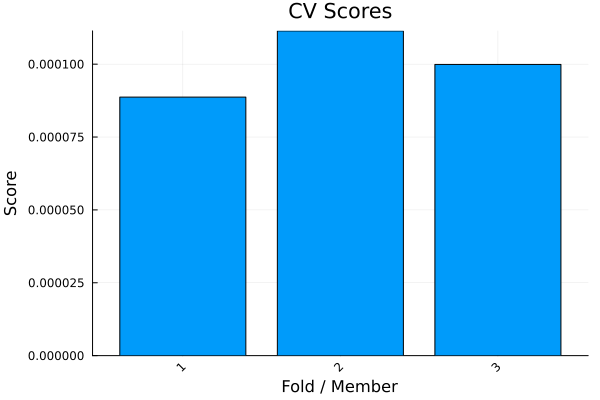

In [8]:
plot_cv_scores(LowOrderMoment(; alg = SecondMoment()), pred)

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*